# Coding Assignment 5

Group: Yifan Liu, Arvind Sankar, Leny Pan, Lucas Schmitt

Netid: yifanl25, asankar2, lenypan2, lucass6

Email: yifanl25@illinois.edu, asankar2@illinois.edu, lenypan2@illinois.edu, lucass6@illinois.edu

Date: 12/08/2025

In [1]:
import kagglehub
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

path = kagglehub.dataset_download("shwetabh123/mall-customers")
original_df = pd.read_csv(path + "/Mall_Customers.csv")
original_df.head()

Using Colab cache for faster access to the 'mall-customers' dataset.


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


----

Problem 1 (50 points)

In this problem we are going to work with the Mall Customers data set from Kaggle – you can download the data directly from Kaggle. This data set contains information about the Annual Income, Spending Score, Age, and Gender of 200 customers. Our goal is to cluster customers into distinct groups based on spending patterns and demographics.

Use one-hot-encoding to convert the categorical variable **gender** to numerical. Also, do not forget to scale (or standardize) the features, since the underlying Euclidean metric in the k-Means algorithm is sensitive to that.

----

In [2]:

# One hot age column
# age_dummies = pd.get_dummies(original_df['Age'], prefix='Age', dtype=int)
# oh_df = pd.concat([original_df, age_dummies], axis=1)
# if 'Age' in oh_df.columns:
#   oh_df = oh_df.drop('Age', axis=1)

oh_df = original_df.copy()
# One for male, 0 for female
if not pd.api.types.is_numeric_dtype(oh_df['Genre']):
  oh_df['Genre'] = np.where(oh_df['Genre'] == 'Male', 1, 0)

y = oh_df['Spending Score (1-100)']
X = oh_df.drop('Spending Score (1-100)', axis=1)

# CustomerID should not be used when clustering
oh_df = oh_df.drop('CustomerID', axis=1)

oh_df_numerical = oh_df[['Annual Income (k$)', 'Spending Score (1-100)', 'Age']]
oh_df_categorical = oh_df.drop(['Annual Income (k$)', 'Spending Score (1-100)', 'Age'], axis=1)

# Scale datapoints
scaler = StandardScaler()
scaled_array = scaler.fit_transform(oh_df_numerical)
scaled_df = pd.DataFrame(scaled_array, columns=oh_df_numerical.columns)
scaled_df = pd.concat([scaled_df, oh_df_categorical], axis=1)
scaled_array = scaled_df.to_numpy()
scaled_df.head()



,Annual Income (k$),Spending Score (1-100),Age,Genre
0,-1.738999,-0.434801,-1.424569,1
1,-1.738999,1.195704,-1.281035,1
2,-1.700830,-1.715913,-1.352802,0
3,-1.700830,1.040418,-1.137502,0
4,-1.662660,-0.395980,-0.563369,0


In [3]:
!pip install git+https://github.com/Mavengence/GapStatistics.git

from gapstatistics import GapStatistics

  Cloning https://github.com/Mavengence/GapStatistics.git to /tmp/pip-req-build-uajeefmc
  Running command git clone --filter=blob:none --quiet https://github.com/Mavengence/GapStatistics.git /tmp/pip-req-build-uajeefmc
  Resolved https://github.com/Mavengence/GapStatistics.git to commit 4dc82f5f5a2cf69adc6c5a539b50b92a3792546a
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for gapstatistics: filename=gapstatistics-0.0.0-py3-none-any.whl size=4558 sha256=78ab8b1dfb0ca33aaa2c5c109769760f17c670976dcc054150f27d0002f6e664
  Stored in directory: /tmp/pip-ephem-wheel-cache-d8g3x1w7/wheels/ac/32/88/ec4d443e01cf5f7971b60bf23612b81422bb1061625e37c0f5
Successfully built gapstatistics


----

**(a)** Use K-Means Clustering to assign each customer to a cluster:

i. Use the Gap Statistic and the Silhouette Statistic to determine the optimal
number of clusters kgap and ksil. Fit the K-means algorithm to the data for both ks.

Note: If you get the same k that is ok! You have more evidence that this is probably
the appropriate number of clusters.

----

In [4]:
np.random.seed(598)
gs = GapStatistics(distance_metric="euclidean")

optimal_clus_for_gap = gs.fit_predict(K=20, X=scaled_array)
print("Number of clusters with best Gap Statistic: ",optimal_clus_for_gap)

Number of clusters with best Gap Statistic:  4


Note: gap statistic is nondeterministic. The chosen K is 4.

In [5]:
from sklearn.metrics import silhouette_score

#scaled_array2 = scaler.fit_transform(oh_df)
silhouette_scores = []
for n in range(2, 21):
  cluster_labels = KMeans(n_clusters=n, random_state=598).fit_predict(scaled_array)
  score = silhouette_score(scaled_array, cluster_labels)
  silhouette_scores.append(score)
optimal_clus_for_sil = silhouette_scores.index(max(silhouette_scores)) + 2
print("Best Silhouette Score: ", max(silhouette_scores))
print("Number of clusters with best Silhouette Score: ",optimal_clus_for_sil)


Best Silhouette Score:  0.356485834425401
Number of clusters with best Silhouette Score:  6


----

ii. Plot the Annual Income vs. Spending Score and color code the clusters for both k's. Comment on the separability of the clusters in each case.

----

In [6]:
kmeans_silhouette = KMeans(n_clusters=optimal_clus_for_sil,
                           random_state=598).fit_predict(scaled_df.to_numpy())
kmeans_gap = KMeans(n_clusters=optimal_clus_for_gap,
                    random_state=598).fit_predict(scaled_df.to_numpy())

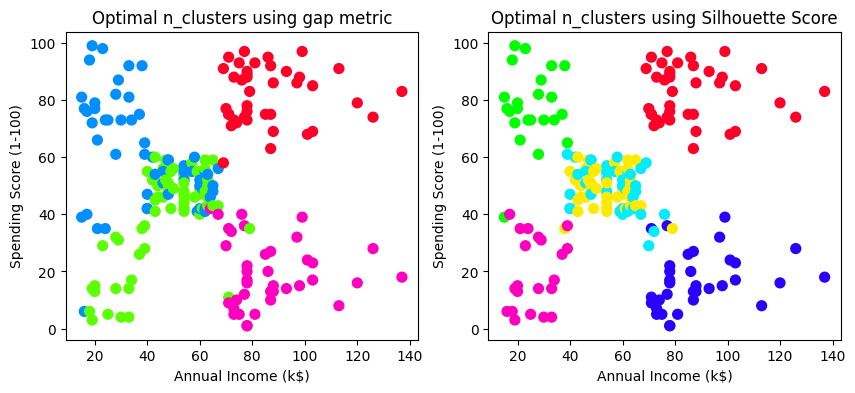

In [7]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

ax1.scatter(oh_df[['Annual Income (k$)']],
            oh_df[['Spending Score (1-100)']],
            c=kmeans_gap, s=50, cmap='gist_rainbow',
            )
ax1.set_title('Optimal n_clusters using gap metric')
ax1.set_xlabel('Annual Income (k$)')
ax1.set_ylabel('Spending Score (1-100)')

ax2.scatter(oh_df[['Annual Income (k$)']],
            oh_df[['Spending Score (1-100)']],
            c=kmeans_silhouette, s=50, cmap='gist_rainbow',
            )
ax2.set_title('Optimal n_clusters using Silhouette Score')
ax2.set_xlabel('Annual Income (k$)')
ax2.set_ylabel('Spending Score (1-100)')

fig.show()

Most the clusters for both the gap statistic and the silhouette statistic are well defined and have clear separability. However, in both cases, there are two clusters with overlap.

In the gap statistic case with 4 clusters, the lime green cluster and the blue cluster overlap in the center region.

In the silhouette statistic case with 6 clusters, the turquoise cluster and the yellow cluster completely overlap in the center region.

In both plots, there are some outlier points that extend into other clusters.

----

iii. Interpret the clusters. For example, you can compute summary statistics for each cluster to understand the customers in each cluster (for each k), e.g. comment on the annual income level, spending score or age. What are your observations?

----


In [8]:
kmeans_silhouette = KMeans(n_clusters=optimal_clus_for_sil,
                           random_state=598).fit(scaled_df)
# labels_silhouette = kmeans_silhouette.labels_
kmeans_gap = KMeans(n_clusters=optimal_clus_for_gap,
                    random_state=598).fit(scaled_df)
labels_gap = kmeans_gap.labels_

examination = original_df.copy()
examination['cluster'] = labels_gap

if not pd.api.types.is_numeric_dtype(examination['Genre']):
  examination['Genre'] = np.where(examination['Genre'] == 'Male', 1, 0)
examination.drop(columns=['CustomerID'], inplace=True)

cluster_summary = examination.groupby('cluster').agg(['mean', 'std'])
print(cluster_summary)


            Genre                  Age            Annual Income (k$)  \
             mean       std       mean        std               mean   
cluster                                                                
0        0.450000  0.503831  32.875000   3.857643          86.100000   
1        0.430769  0.499038  53.984615   9.418221          47.707692   
2        0.403509  0.494962  25.438596   5.707193          40.000000   
3        0.500000  0.506712  39.368421  10.617225          86.500000   

                   Spending Score (1-100)             
               std                   mean        std  
cluster                                               
0        16.339036              81.525000   9.999968  
1        14.648723              39.969231  16.405953  
2        17.031483              60.298246  18.434212  
3        16.761845              19.578947  11.684204  


For the gap statistic analysis:

The first cluster shows an average age of 33, income of 86k, and spending score of around 82 while being on average 45% male. This group represents relatively young upper middle class shoppers with a proclivity for spending, being loyal, and showing up frequently to shop. This indicates that this group is high value for stores because of high activity.

The second cluster shows an average age of 54, income of 48k, and spending score of around 40 while being on average 43% male. This group is comprised of older shoppers with less money than the first cluster. The spending score for this group of seniors is lower indicating more budget conscious consumption and probably less overall visits.

The third cluster has an average age of 25, income of 40k, and spending score of 60 while being on average 40% male. This group is the youngest has a high spending score. This group is likely spending beyond their means since they have the lowest income but are quite active and likely follow trends.

The fourth cluster has an average age of 39, income of 87K, and spending score of 20, while being on average 50% male. This group is also upper middle class but slightly older near middle age. This group has the lowest spending score and likely focuses more on saving.

The aforementioned overlap between the blue and lime green clusters are between the second and third clusters, i.e., the lower spending score individuals of the third cluster and the higher spending score individuals of the second cluster.

Ultimately for all clusters, gender is not a particularly substantial factor in final spending score as most clusters were fairly balanced.

In [9]:
kmeans_silhouette = KMeans(n_clusters=optimal_clus_for_sil,
                           random_state=598).fit(scaled_df)
# labels_silhouette = kmeans_silhouette.labels_
kmeans_gap = KMeans(n_clusters=optimal_clus_for_gap,
                    random_state=598).fit(scaled_df)
labels_gap = kmeans_silhouette.labels_

examination = original_df.copy()
examination['cluster'] = labels_gap

if not pd.api.types.is_numeric_dtype(examination['Genre']):
  examination['Genre'] = np.where(examination['Genre'] == 'Male', 1, 0)
examination.drop(columns=['CustomerID'], inplace=True)

cluster_summary = examination.groupby('cluster').agg(['mean', 'std'])
print(cluster_summary)


            Genre                  Age            Annual Income (k$)  \
             mean       std       mean        std               mean   
cluster                                                                
0        0.461538  0.505035  32.692308   3.728650          86.538462   
1        0.422222  0.499495  56.333333   8.453079          54.266667   
2        0.434783  0.506870  25.000000   5.300086          25.260870   
3        0.342105  0.480783  27.000000   7.032742          56.657895   
4        0.588235  0.499554  41.264706  10.768385          88.500000   
5        0.380952  0.497613  45.523810  11.766984          26.285714   

                   Spending Score (1-100)             
               std                   mean        std  
cluster                                               
0        16.312485              82.128205   9.364489  
1         8.975725              49.066667   6.300794  
2         7.723738              77.608696  13.272457  
3         9.905708   

For the silhouette statistic analysis:

The first cluster is comprised of individuals on average age 33, income 87k, and a very high spending score of 82 while being 46% male. This group is high income relatively young active shoppers that likely visit stores frequently and have a proclivity for spending.

The second cluster is comprised of individuals on average age 56, income 54k, and a spending score of 49 while being 42% male. This group is middle income seniors and has an average spending score indicating normal levels of spending and average shopping activity.

The third cluster is comprised of individuals on average age 25, income 25k, and a spending score of 78 while being 43% male. This group is young active shoppers that are likely overspending beyond their means. This group likely visits stores often and purchase frequently.

The fourth cluster is comprised of individuals on average age 27, income 57k, and a spending score of 49 while being 34% male. This group is young and spends an average amount and likely has average shopping activity.

The fifth cluster is comprised of individuals on average age 41, income 89k, and a spending score of 17 while being 59% male. This group is middle age high income but very frugal and likely focused on saving.

The sixth cluster is comprised of individuals on average age 46, income 26k, and a spending score of 19 while being 38% male. This group is middle age and low income and lives frugally without excessive spending or shopping activity.


The clusters that overlap (the yellow and turquoise clusters on the silhouette statistic graph) correspond to the second and fourth clusters in the above analysis. Both these groups are solidly middle income and average the same spending scores of 49.

In both the 4 cluster and 6 cluster cases, younger individuals were likely to have higher spending scores. The income was not correlated with spending score.


----

**(b)** Use Hierarchical Clustering to assign a cluster to each customer:

i. Plot the dendrogram for the data.

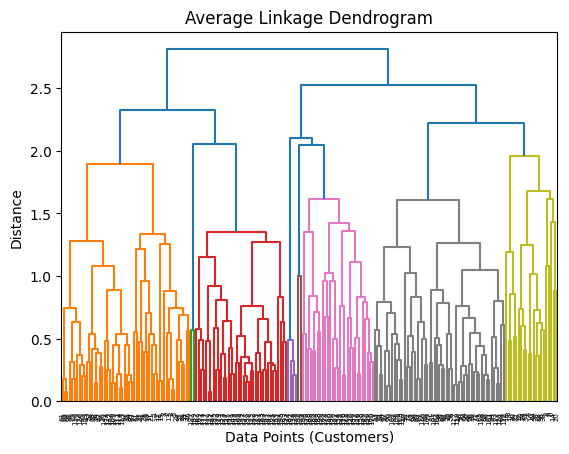

In [10]:
from scipy.cluster.hierarchy import linkage, dendrogram

average_clustering = linkage(scaled_df, method="average", metric="euclidean")

dendrogram(average_clustering)
plt.title("Average Linkage Dendrogram")
plt.xlabel("Data Points (Customers)")
plt.ylabel("Distance")
plt.show()

----

ii. Repeat questions (a - ii) and (a - iii) for the results of hierarchical clustering and comment on the differences and/or similarities with what you got in part (a).

----

In [11]:
# Gap statistic for hierarchical clusters
# Reference: https://www.geeksforgeeks.org/machine-learning/gap-statistics-for-optimal-number-of-cluster/
from sklearn.cluster import AgglomerativeClustering

def compute_inertia(X, labels):
  # compute mean, then sum of squares from that mean
  Wk = 0
  for cluster in np.unique(labels):
    pts = X[labels == cluster]
    centroid = pts.mean(axis=0)
    Wk += ((pts - centroid)**2).sum()
  return Wk

def optimalK(X, k_max, n_replicates=10):
    gaps = np.zeros(k_max - 1)
    rows = []
    gap_std = []
    for gap_index, k in enumerate(range(1, k_max)):
        reference_inertias = np.zeros(n_replicates)
        for i in range(n_replicates):
            np.random.seed(598)
            randomReference = np.random.random_sample(size=X.shape)

            hc_ref = AgglomerativeClustering(n_clusters=k, linkage="average")
            ref_labels = hc_ref.fit_predict(randomReference)

            reference_inertias[i] = compute_inertia(randomReference, ref_labels)

            hc = AgglomerativeClustering(n_clusters=k, linkage="average")
        X_labels = hc.fit_predict(X)
        x_inertias = compute_inertia(X, X_labels)

        gap = np.log(reference_inertias.mean()) - np.log(x_inertias)
        gaps[gap_index] = gap

        std = np.sqrt(1 + 1/n_replicates) * np.std(np.log(reference_inertias))
        gap_std.append(std)
        rows.append(gap)
    return gaps.argmax() + 1, rows, gap_std
score_g, rows, gap_std = optimalK(scaled_array, k_max = 20, n_replicates = 50)
print(score_g)
for k in range(len(rows) - 1):
    if rows[k] >= rows[k+1] - gap_std[k+1]:
        print(k + 1)
        break

5
5


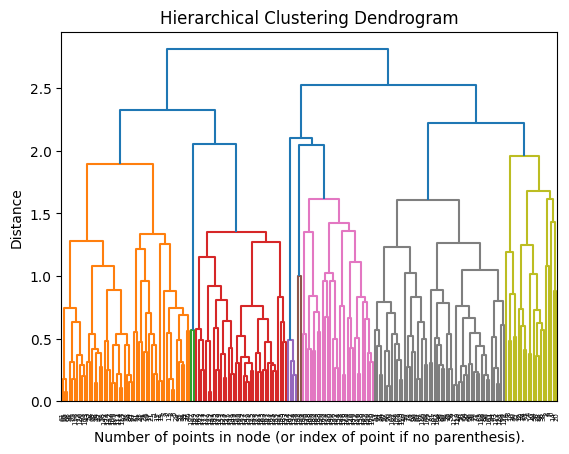

In [12]:
from sklearn.cluster import AgglomerativeClustering
# agglo_cluster = AgglomerativeClustering(n_clusters=optimal_clus_for_gap,
agglo_cluster = AgglomerativeClustering(distance_threshold=0, linkage="average", n_clusters=None)
agglo_labels = agglo_cluster.fit(scaled_array)


def plot_dendrogram(model, **kwargs):
    # Create linkage matrix and then plot the dendrogram

    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix, **kwargs)
plt.title("Hierarchical Clustering Dendrogram")
# plot the top three levels of the dendrogram
plot_dendrogram(agglo_cluster, truncate_mode="level")
plt.xlabel("Number of points in node (or index of point if no parenthesis).")
plt.ylabel("Distance")
plt.show()

In [13]:
hierarchical = AgglomerativeClustering(n_clusters=5, linkage='average')
labels_hierarchical = hierarchical.fit_predict(scaled_array)

Text(0, 0.5, 'Spending Score (1-100)')

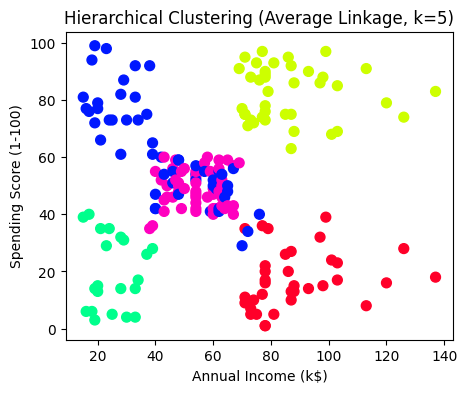

In [25]:
fig, ax1 = plt.subplots(nrows=1, figsize=(5, 4))

ax1.scatter(oh_df[['Annual Income (k$)']],
            oh_df[['Spending Score (1-100)']],
            c=labels_hierarchical, s=50, cmap='gist_rainbow',
            )
ax1.set_title('Hierarchical Clustering (Average Linkage, k=5)')
ax1.set_xlabel('Annual Income (k$)')
ax1.set_ylabel('Spending Score (1-100)')

The separation of clusters for the hierarchical clustering has three well separated clusters. However, the indigo and pink clusters overlap in the middle income and average spending score range.

In [26]:
examination = original_df.copy()
examination['cluster'] = labels_hierarchical

if not pd.api.types.is_numeric_dtype(examination['Genre']):
    examination['Genre'] = np.where(examination['Genre'] == 'Male', 1, 0)
examination.drop(columns=['CustomerID'], inplace=True)

cluster_summary = examination.groupby('cluster').agg(['mean', 'std'])
print(cluster_summary)

            Genre                  Age            Annual Income (k$)  \
             mean       std       mean        std               mean   
cluster                                                                
0        0.571429  0.502096  41.685714  10.897305          88.228571   
1        0.461538  0.505035  32.692308   3.728650          86.538462   
2        0.380952  0.497613  44.142857  13.089254          25.142857   
3        0.384615  0.491251  24.653846   4.942352          42.942308   
4        0.415094  0.497454  53.339623  10.412536          54.490566   

                   Spending Score (1-100)             
               std                   mean        std  
cluster                                               
0        16.367266              17.285714  10.211215  
1        16.312485              82.128205   9.364489  
2         7.226934              19.523810  12.769569  
3        17.571605              62.076923  17.428674  
4         8.454909              48.943

The first cluster has an average age of 42, income of 88k, and spending score of 17 while having on average 57% males. This group represents affluent middle aged high income individuals. This group, however, has a low spending score; they're likely focused on saving and extremely frugal with store purchases.

The second cluster has an average age of 33, income of 87k, and spending score of 82 while having on average 46% males. This group is affluent relatively young and has high income with a propensity to spend. This group likely has high shopping activity and makes purchases frequently.

The third cluster has an average age of 44, income of 25k, and spending score of 20 while having on average 38% males. This group represents low income middle aged individuals. This group has a low spending score and likely does not spend frequently and has low shopping activity.

the fourth cluster has an average age of 25, income of 43k, and spending score of 62 while having on average 38% males. This group represents affluent high income individuals. This group young individuals with relatively high proclivity for spending and moderate income. They're likely very active shoppers.

The fifth cluster has an average age of 53, income of 54k, and a spending score of 49 while having on average 42% males. This group is composed of senior aged shoppers with moderate income and moderate spending/activity.

The fifth cluster and the fourth cluster correspond to the pink and indigo clusters which overlap at the center of the plot.

Again, it can be seen that amount of annual income does not correspond with spending score. This conclusion is the same in part (a). It is also apparent, just like part (a), that gender again does not have a notable influence of clustering as most clusters were relatively balanced between the genders. Like part (a), this hierarchical clustering approach did not achieve perfect separation. A difference was that the hierarchical clustering approach produced 5 clusters compared to the kmeans gap statistic and silhouette statistic which yielded 4 and 6 clusters, respectively.

The hierarchical clustering approach has 1 cluster that is relatively old (40s) and very low income (25k). A similiar cluster appeared in the kmeans silhouette statistic apporach but not in the kmeans gap statistic approach.

----

### Problem 2 (50 points)

In this problem we are going to create a simulated data set to illustrate the use of spectral clustering. In the literature, what we are going to simulate is known as the “Two Moons” data. Mathematically, each half moon is nothing by a half semi-circle of radius r that can be
parametrized using polar coordinates as `x = rcos(θ)`, `y = r sin(θ)`
if it is the upper half, and `x' = dx − rcos(θ)`, `y' = −r sin(θ) − dy`
the lower half slightly shifted in each coordinate by dx and dy (so that the two half circles do
not overlap. Here θ ∈ [0, π] and r is the radius.

----

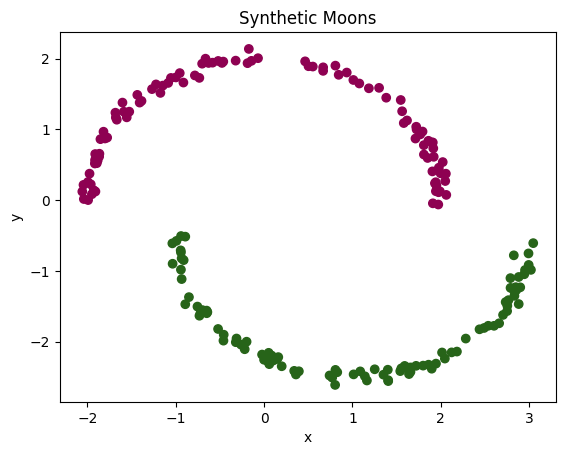

In [18]:
import random
import math

random.seed(598)
x = []
y = []
label = []
r = 2
for i in range(200):
  theta = random.uniform(0, math.pi)
  rand1 = random.normalvariate(mu=0, sigma=0.05)
  rand2 = random.normalvariate(mu=0, sigma=0.05)
  if i % 2 == 0:
    x.append(r * math.cos(theta) + rand1)
    y.append(r * math.sin(theta) + rand2)
    label.append(0)
  else:
    x.append(1-2*math.cos(theta) + rand1)
    y.append(-2*math.sin(theta) - 0.5 + rand2)
    label.append(1)
plots = {
    "x": x,
    "y": y,
    "label": label
}
df = pd.DataFrame(plots)

plt.scatter(df['x'], df['y'], c=df['label'], cmap="PiYG")
plt.title("Synthetic Moons")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

----

## 2a

Use K-Means Clustering to assign each point to a cluster (use k = 2). Plot the results by color-coding the data by cluster assignment. Comment on the results

----

Misclassification rate using kmeans: 12.5%


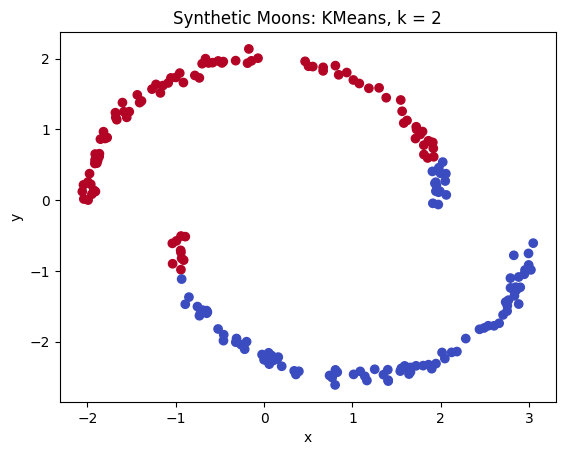

In [19]:
def calc_misclassification_rate(y, yhat):
  labels_match = sum(a == b for a, b in zip(y, yhat)) / len(yhat)
  labels_dont_match = sum(a != b for a, b in zip(y, yhat)) / len(yhat)
  # Getting everything wrong is the same as getting everything right. Take the
  # lower of the two errors
  return min(labels_match, labels_dont_match) * 100

kmeans_res = KMeans(n_clusters=2,
                    random_state=598).fit_predict(df.to_numpy())

plt.scatter(df['x'], df['y'], c=kmeans_res, cmap="coolwarm")
plt.title("Synthetic Moons: KMeans, k = 2")
plt.xlabel("x")
plt.ylabel("y")
print(f"Misclassification rate using kmeans: {calc_misclassification_rate(label, kmeans_res)}%")
plt.show()

From the above plot of applying kmeans clustering to out dataset, we can see that the kmeans algorithm does a fair job at classifying the points. Despite the points being clearly in separable clusters, 12.5% the points are misclassified. The points that are misclassified are closest in distance to the points of the other cluster.

----

## 2b
Use Spectral Clustering to the same data set (use k = 2). Plot the results by colorcoding the data by cluster assignment. Comment on the results and compare with part (a) above.

----

Misclassification rate using Spectral Clustering: 0.0%


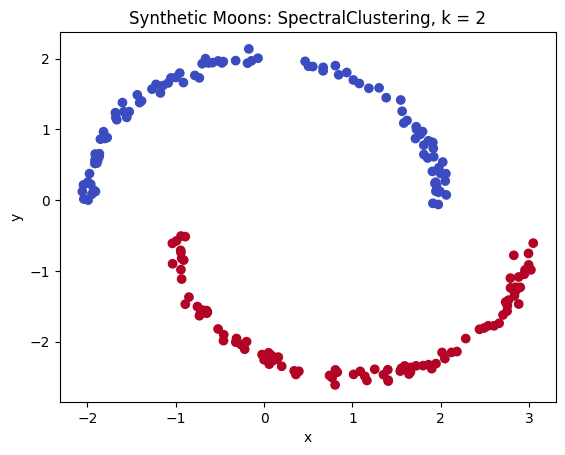

In [20]:
from sklearn.cluster import SpectralClustering

sc = SpectralClustering(n_clusters=2, affinity='rbf', random_state=598)
sc.fit(df.drop('label', axis=1))
sc_res = sc.labels_

print(f"Misclassification rate using Spectral Clustering: {calc_misclassification_rate(label, sc_res)}%")

plt.scatter(df['x'], df['y'], c=sc_res, cmap="coolwarm")
plt.title("Synthetic Moons: SpectralClustering, k = 2")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

Spectral clustering performs much better than kmeans clustering in grouping the moons from this example. The spectral clustering algorithm properly classifies every data point. This may be because spectral clustering focuses more on point-connectivity rather than distance between points, which allows it to perform better in situations like this where clusters are clearly joined to each other and separated from other clusters.

#BONUS:

For reference, the same test was performed using Agglomerative clustering. Agglomerative clustering and Spectral clustering both depend on the similarity of points, rather than a euclidean distance to a mean, allowing them to better represent

Misclassification rate using Agglomerative Clustering: 0.0%


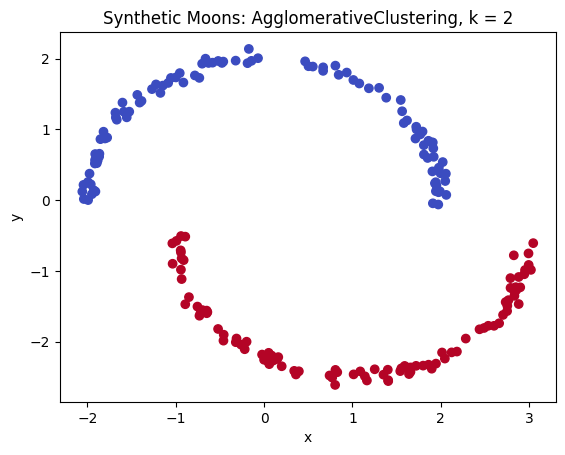

In [21]:
aggloclus_res = AgglomerativeClustering(n_clusters=2, linkage='complete').fit_predict(df.to_numpy())

plt.scatter(df['x'], df['y'], c=aggloclus_res, cmap="coolwarm")
plt.title("Synthetic Moons: AgglomerativeClustering, k = 2")
plt.xlabel("x")
plt.ylabel("y")

print(f"Misclassification rate using Agglomerative Clustering: {calc_misclassification_rate(label, aggloclus_res)}%")
plt.show()

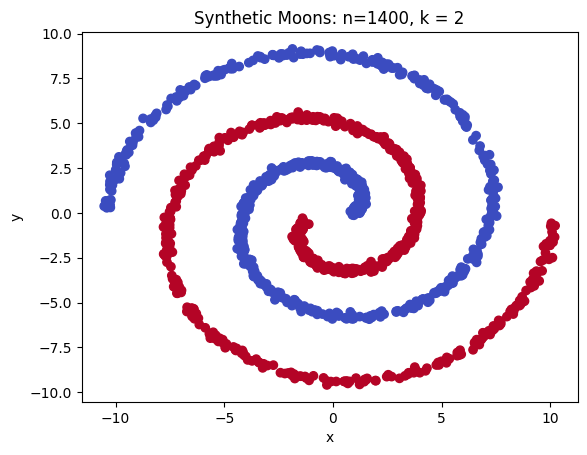

In [22]:
random.seed(598)
x = []
y = []
label = []
r = 2
for i in range(700):
  theta = random.uniform(0, 3 * math.pi)
  rand1 = random.normalvariate(mu=0, sigma=0.1)
  rand2 = random.normalvariate(mu=0, sigma=0.1)
  x.append(((r * (theta + 1)/2) * math.cos(theta) + rand1))
  y.append(((r * (theta + 1)/2) * math.sin(theta) + rand2))
  label.append(0)
for i in range(700):
  angle = random.uniform(0, 3 * math.pi)
  rand1 = random.normalvariate(mu=0, sigma=0.1)
  rand2 = random.normalvariate(mu=0, sigma=0.1)
  x.append((-(r * (angle + 1)/2)*math.cos(angle) + rand1) - 0.3)
  y.append((-(r * (angle + 1)/2)*math.sin(angle) + rand2) - 0.5)
  label.append(1)

plots = {
    "x": x,
    "y": y,
    "label": label
}
df = pd.DataFrame(plots)

plt.scatter(df['x'], df['y'], c=df['label'], cmap="coolwarm")
plt.title("Synthetic Moons: n=1400, k = 2")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

Misclassification rate using Spectral Clustering: 35.0%


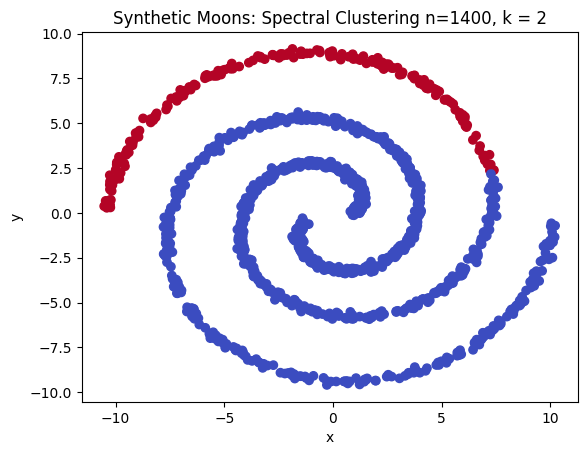

In [23]:
sc = SpectralClustering(n_clusters=2, affinity='rbf', random_state=598)
sc.fit(df.drop('label', axis=1))
sc_res = sc.labels_

print(f"Misclassification rate using Spectral Clustering: {calc_misclassification_rate(label, sc_res)}%")

plt.scatter(df['x'], df['y'], c=sc_res, cmap="coolwarm")
plt.title("Synthetic Moons: Spectral Clustering n=1400, k = 2")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

Misclassification rate using Agglomerative Clustering: 35.0%


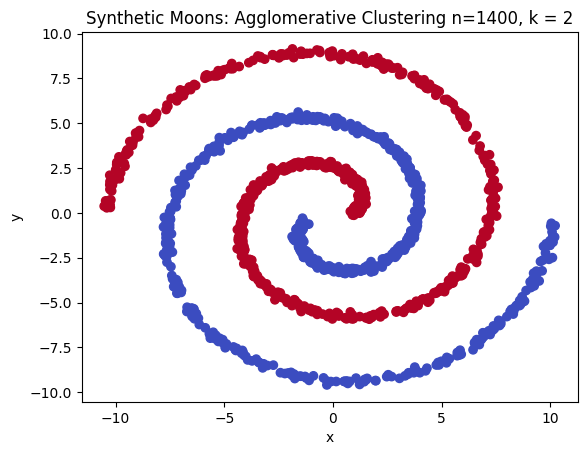

In [24]:
aggloclus_res = AgglomerativeClustering(n_clusters=2, linkage='single').fit_predict(df.to_numpy())

plt.scatter(df['x'], df['y'], c=aggloclus_res, cmap="coolwarm")
plt.title("Synthetic Moons: Agglomerative Clustering n=1400, k = 2")
plt.xlabel("x")
plt.ylabel("y")
print(f"Misclassification rate using Agglomerative Clustering: {calc_misclassification_rate(label, sc_res)}%")
plt.show()